# Artemis Router Quickstart

Welcome to the Artemis VLM Router! This notebook will get you up and running in seconds. 

**Goal:** Load a pre-trained router and make a decision for a single image and prompt.

---

In [1]:
# 1. Setup Paths
import sys
import os
from pathlib import Path

# Ensure we can see the 'artemis_final' package
# Assuming this notebook is in examples/router/, we go up two levels
current_dir = Path(os.getcwd())
project_root = current_dir.parent.parent
sys.path.append(str(project_root))

print(f"Project root added to path: {project_root}")

try:
    import artemis_final
    print("Successfully imported artemis_final")
except ImportError as e:
    print(f"Failed to import artemis_final: {e}")
    print("Please ensure you are running this notebook from the examples/router directory")

Project root added to path: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router
Successfully imported artemis_final


In [2]:
# 2. Load the Router
from artemis_final.router.public_api import load_router_from_checkpoint

print("Loading Multitask Reward Router...")
# We use the 'reward' router as it provides the most advanced routing capabilities.
ckpt_path = project_root / "artemis_final" / "checkpoints" / "best_multitask_router_v1.pt"

if not ckpt_path.exists():
    print(f"Checkpoint not found at {ckpt_path}. Checking alternative location...")
    # Fallback for alternative structure
    ckpt_path = project_root / "artemis_final" / "router_train" / "models" / "checkpoints" / "best_reward_router.pt"

if ckpt_path.exists():
    router = load_router_from_checkpoint(router_type="reward", checkpoint_path=str(ckpt_path))
    print(f"\n Router loaded: {type(router).__name__}")
else:
    print(f"Error: Could not find checkpoint at {ckpt_path}")

Loading Multitask Reward Router...
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30

 Router loaded: RewardRouterInference


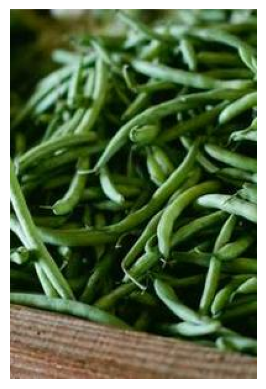

In [3]:
# 3. Load a Sample Image
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

def get_sample_image():
    # Try to load a simple image from the web, fallback to a local generated one if offline
    url = "https://picsum.photos/200/300" # Simple lightweight image
    try:
        response = requests.get(url, timeout=5)
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception:
        print("Could not fetch web image, creating boolean dummy image")
        return Image.new('RGB', (224, 224), color = 'red')

image = get_sample_image()
plt.imshow(image)
plt.axis('off')
plt.show()

In [4]:
# 4. Route!
# We ask a question about the image and see which model the router picks.
prompt = "What is shown in this image?"

# route() returns the selected model name and some metadata
# Note: usage depends on the specific router implementation, but typically accepts image and prompt
decision = router.route(image, prompt, mode="balanced")

print(f"Image Size: {image.size}")
print(f"Prompt: '{prompt}'")
print(decision)
print(f"\n Router Selected Model: **{decision['chosen_model']}**")
# Try to safely access confidence/score metadata as it varies by router type
score = getattr(decision, 'score', None)
if score is None and hasattr(decision, 'probs'):
    score = max(decision.probs.values())
# print(f"Router Confidence: {score if score else 'N/A'}")

[INFO] Detected swapped arguments in route(). Swapping prompt and image.
Image Size: (200, 300)
Prompt: 'What is shown in this image?'
{'chosen_model': 'qwen2_5_vl_3b', 'chosen_model_id': 2, 'rewards': {'deepseek_ocr': 0.5002115964889526, 'gemma_3_27b': 0.4616869390010834, 'qwen2_5_vl_3b': 0.5024724006652832, 'qwen2_5_vl_7b': 0.47185078263282776, 'qwen3_vl_8b_thinking': 0.39334991574287415}, 'mode': 'balanced', 'inference_ms': 36.18001937866211}

 Router Selected Model: **qwen2_5_vl_3b**


In [5]:
# 4. Route!
# We ask a question about the image and see which model the router picks.
prompt = "What is shown in this image?"

# route() returns the selected model name and some metadata
# Note: usage depends on the specific router implementation, but typically accepts image and prompt
decision = router.route(image, prompt, mode="accuracy")

print(f"Image Size: {image.size}")
print(f"Prompt: '{prompt}'")
print(decision)
print(f"\n Router Selected Model: **{decision['chosen_model']}**")
# Try to safely access confidence/score metadata as it varies by router type
score = getattr(decision, 'score', None)
if score is None and hasattr(decision, 'probs'):
    score = max(decision.probs.values())
# print(f"Router Confidence: {score if score else 'N/A'}")

[INFO] Detected swapped arguments in route(). Swapping prompt and image.
Image Size: (200, 300)
Prompt: 'What is shown in this image?'
{'chosen_model': 'qwen2_5_vl_3b', 'chosen_model_id': 2, 'rewards': {'deepseek_ocr': 0.009012393653392792, 'gemma_3_27b': 0.00023017078638076782, 'qwen2_5_vl_3b': 0.018060699105262756, 'qwen2_5_vl_7b': 0.008793964982032776, 'qwen3_vl_8b_thinking': 0.0052347928285598755}, 'mode': 'accuracy', 'inference_ms': 23.801088333129883}

 Router Selected Model: **qwen2_5_vl_3b**


<!-- ## Comparison
Wait, why did it pick that model? 

The generic `route` method defaults to a balanced or accuracy-focused mode (depending on config). 

To see how to control cost vs speed vs accuracy, check out the next notebook: **[01_router_modes_and_architectures.ipynb](01_router_modes_and_architectures.ipynb)** -->